<a href="https://colab.research.google.com/github/davirodrigues2026/Fonte-de-informa-o-e-Banco-de-dados/blob/main/15_05_Banco_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [4]:
import os
import pandas as pd

# List files in the downloaded dataset directory
files = os.listdir(path)
print(f"Files in the dataset directory: {files}")

# Assuming there's a CSV file, find it and load it
csv_file = [f for f in files if f.endswith('.csv') or f.endswith('.txt')]

if csv_file:
    data_file_path = os.path.join(path, csv_file[0])
    df = pd.read_csv(data_file_path)
    print("\nData loaded successfully!")
    print(df.head())
else:
    print("No CSV or text file found in the dataset directory.")


Files in the dataset directory: ['Ice Cream Sales - temperatures.csv']

Data loaded successfully!
   Temperature  Ice Cream Profits
0           39              13.17
1           40              11.88
2           41              18.82
3           42              18.65
4           43              17.02


In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Define features (X) and target (y)
X = df['Temperature'].values.reshape(-1, 1) # Reshape for sklearn
y = df['Ice Cream Profits'].values

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get the coefficients
slope = model.coef_[0]
intercept = model.intercept_

print(f"Linear Regression Equation: Ice Cream Profits = {slope:.2f} * Temperature + {intercept:.2f}")
print(f"Coefficient (Slope): {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"{model.coef_[0]:.2f}x+{model.intercept_: .2f}")

Linear Regression Equation: Ice Cream Profits = 1.19 * Temperature + -33.70
Coefficient (Slope): 1.19
Intercept: -33.70
1.19x+-33.70


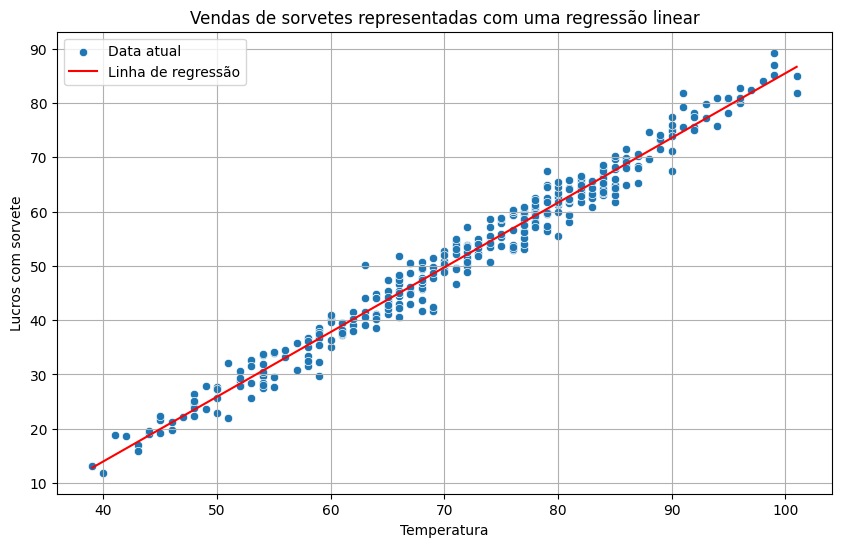

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict values using the model for plotting the regression line
y_pred = model.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Ice Cream Profits', data=df, label='Data atual')
plt.plot(X, y_pred, color='red', label='Linha de regressão')
plt.title('Vendas de sorvetes representadas com uma regressão linear')
plt.xlabel('Temperatura')
plt.ylabel('Lucros com sorvete')
plt.grid(True)
plt.legend()
plt.show()